In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



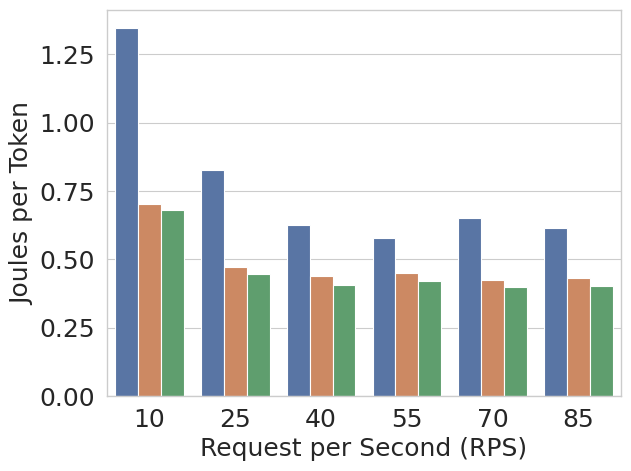

In [7]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/synthetic_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_B5_1': 'Distserve 85',
    'DISTSERVE_R5_JAN3_B5_2': 'Distserve 70',
    'DISTSERVE_R5_JAN3_B5_3': 'Distserve 55',
    'DISTSERVE_R5_JAN3_B5_4': 'Distserve 40',
    'DISTSERVE_R5_JAN3_B5_5': 'Distserve 25',
    'DISTSERVE_R5_JAN3_B5_6': 'Distserve 10',
    'OURS_R5_JAN3_B5_1': 'PlaceOnly 85',
    'OURS_R5_JAN3_B5_2': 'PlaceOnly 70',
    'OURS_R5_JAN3_B5_3': 'PlaceOnly 55',
    'OURS_R5_JAN3_B5_4': 'PlaceOnly 40',
    'OURS_R5_JAN3_B5_5': 'PlaceOnly 25',
    'OURS_R5_JAN3_B5_6': 'PlaceOnly 10',
    'OURS_R5_JAN3_B5_1_DVFS': 'BiScale 85',
    'OURS_R5_JAN3_B5_2_DVFS': 'BiScale 70',
    'OURS_R5_JAN3_B5_3_DVFS': 'BiScale 55',
    'OURS_R5_JAN3_B5_4_DVFS': 'BiScale 40',
    'OURS_R5_JAN3_B5_5_DVFS': 'BiScale 25',
    'OURS_R5_JAN3_B5_6_DVFS': 'BiScale 10',
    'OURS_R5_JAN3_B5_1_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_B5_2_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_B5_3_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_B5_4_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_B5_5_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_B5_6_DVFS_W': 'BiScale 10',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_B5_6_DVFS', 'OURS_R5_JAN3_B5_5_DVFS',
    'OURS_R5_JAN3_B5_4_DVFS', 'OURS_R5_JAN3_B5_3_DVFS',
    'OURS_R5_JAN3_B5_2_DVFS', 'OURS_R5_JAN3_B5_1_DVFS'
])]
# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)

# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=18)
ax.set_ylabel('Joules per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=18)
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/plot_8.1a_energy_synthetic.pdf", format="pdf")


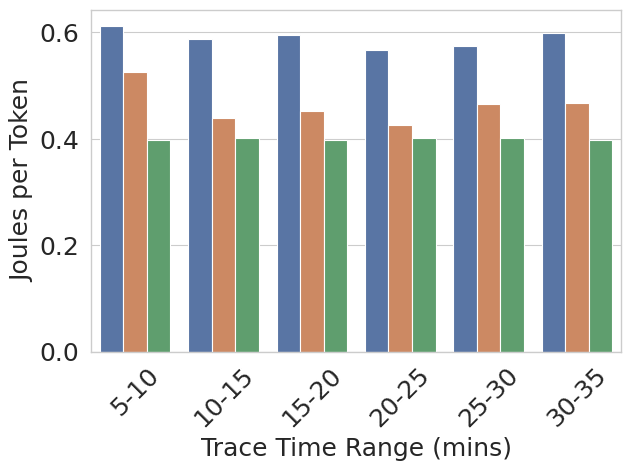

In [8]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_REAL_P85_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_REAL_P85_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_REAL_P85_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_REAL_P85_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_REAL_P85_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS': 'BiScale 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'BiScale 10',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS'
])]
# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Joules per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/plot_8.1b_energy_85p.pdf", format="pdf")

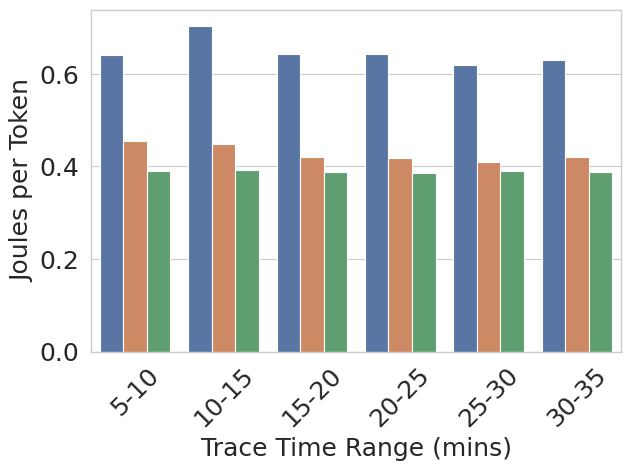

In [9]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_OLD_P90_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_OLD_P90_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_OLD_P90_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_OLD_P90_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_OLD_P90_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_OLD_P90_6_DVFS': 'BiScale 85',
    'OURS_R5_JAN3_OLD_P90_5_DVFS': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_4_DVFS': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_3_DVFS': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_2_DVFS': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_1_DVFS': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_W': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_W': 'BiScale 85',
}

df_results = df_results[~df_results['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=18)
ax.set_ylabel('Joules per Token', fontsize=18)
ax.set_xticks([0, 1, 2, 3, 4, 5])  # Set the positions of the x-axis ticks
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=18, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=18)  # Adjust the font size of y-axis tick labels
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/plot_8.1b_energy_67p.pdf", format="pdf")